<a href="https://colab.research.google.com/github/Ramcharan-2/ML-p/blob/main/miproject24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("/content/fashion_sales_5000_rows.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/fashion_sales_5000_rows.csv'

In [ ]:
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()
le5 = LabelEncoder()

df['Season'] = le1.fit_transform(df['Season'])
df['Product_Type'] = le2.fit_transform(df['Product_Type'])
df['Fabric'] = le3.fit_transform(df['Fabric'])
df['Gender'] = le4.fit_transform(df['Gender'])
df['Region'] = le5.fit_transform(df['Region'])

In [ ]:
print(df['Sales_Category'].value_counts())

Sales_Category
1    1833
0    1832
2    1335
Name: count, dtype: int64


As we can see, the classes are somewhat imbalanced. Class `2` (High Sales) has significantly fewer samples than classes `0` and `1`. This imbalance can cause models to struggle with predicting the minority class.

To address this and potentially increase accuracy, I recommend trying a more sophisticated model like `RandomForestClassifier`, which is less sensitive to class imbalance and generally performs well on a wide range of datasets. We can also explicitly try to handle class imbalance if needed by using `class_weight='balanced'` for the `LogisticRegression` model, or by using sampling techniques, but let's start with a new model.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate and train a RandomForestClassifier with class weights adjusted for imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_c, y_train_c)

# Make predictions
y_pred_rf = rf_model.predict(X_test_c)

# Evaluate the model
print("Random Forest Classifier Accuracy (with balanced class weights):", accuracy_score(y_test_c, y_pred_rf))
print(classification_report(y_test_c, y_pred_rf))

Random Forest Classifier Accuracy (with balanced class weights): 0.361
              precision    recall  f1-score   support

           0       0.38      0.43      0.40       357
           1       0.37      0.42      0.39       379
           2       0.30      0.19      0.23       264

    accuracy                           0.36      1000
   macro avg       0.35      0.34      0.34      1000
weighted avg       0.35      0.36      0.35      1000



In [ ]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lin = lin_model.predict(X_test)

In [ ]:
print("Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("MAE:", mean_absolute_error(y_test, y_pred_lin))

Linear Regression Results
R2 Score: 0.0002568531184042877
MSE: 29446842.930074118
MAE: 4681.245011988398


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def sales_category(s):
    if s > 15000:
        return 2  # High
    elif s > 8000:
        return 1  # Medium
    else:
        return 0  # Low

df['Sales_Category'] = df['Sales'].apply(sales_category)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split # Added import statement
from sklearn.linear_model import LogisticRegression # Added import statement
from sklearn.metrics import accuracy_score, classification_report # Added import statement for accuracy_score and classification_report

X_class = df.drop(['Sales', 'Sales_Category'], axis=1)
y_class = df['Sales_Category']

# Scale the classification features
scaler_class = StandardScaler()
X_class_scaled = scaler_class.fit_transform(X_class)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_scaled, y_class, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

y_pred_log = log_model.predict(X_test_c)

print("Logistic Regression Accuracy:", accuracy_score(y_test_c, y_pred_log))
print(classification_report(y_test_c, y_pred_log))

Logistic Regression Accuracy: 0.391
              precision    recall  f1-score   support

           0       0.37      0.61      0.46       357
           1       0.42      0.46      0.44       379
           2       0.00      0.00      0.00       264

    accuracy                           0.39      1000
   macro avg       0.26      0.36      0.30      1000
weighted avg       0.29      0.39      0.33      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


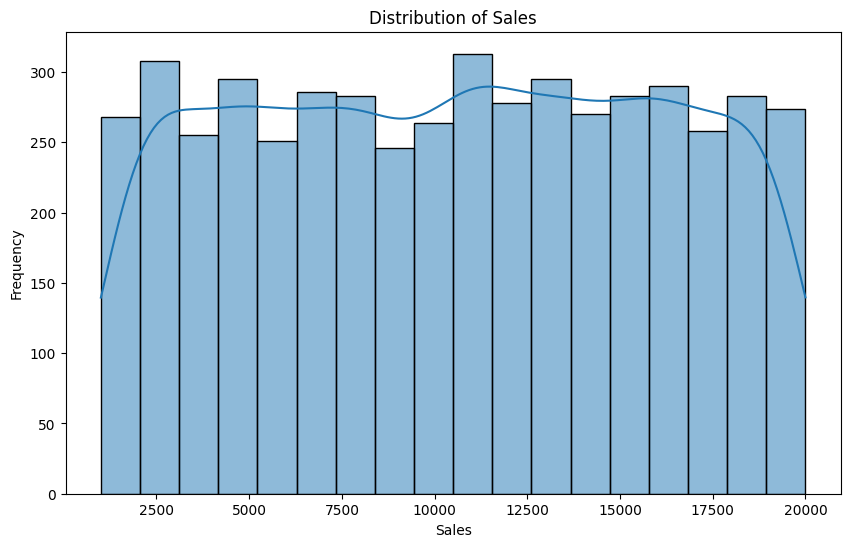

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is defined and preprocessed
df = pd.read_csv("/content/fashion_sales_5000_rows.csv")

le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()
le5 = LabelEncoder()

df['Season'] = le1.fit_transform(df['Season'])
df['Product_Type'] = le2.fit_transform(df['Product_Type'])
df['Fabric'] = le3.fit_transform(df['Fabric'])
df['Gender'] = le4.fit_transform(df['Gender'])
df['Region'] = le5.fit_transform(df['Region'])

def sales_category(s):
    if s > 15000:
        return 2  # High
    elif s > 8000:
        return 1  # Medium
    else:
        return 0  # Low

df['Sales_Category'] = df['Sales'].apply(sales_category)

# Original plotting code
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# Ensure X and y are defined for the regression task
X = df.drop("Sales", axis=1)
y = df["Sales"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

svm_model = SVR(kernel='rbf', C=100)
svm_model.fit(X_train_s, y_train_s)

y_pred_svm = svm_model.predict(X_test_s)

print("SVM Regression Results")
print("R2 Score:", r2_score(y_test_s, y_pred_svm))
print("MSE:", mean_squared_error(y_test_s, y_pred_svm))

SVM Regression Results
R2 Score: 0.8312368816284771
MSE: 4970817.809131036


Let's examine how 'Sales' varies across different categorical features like 'Season', 'Product_Type', 'Gender', and 'Region'.

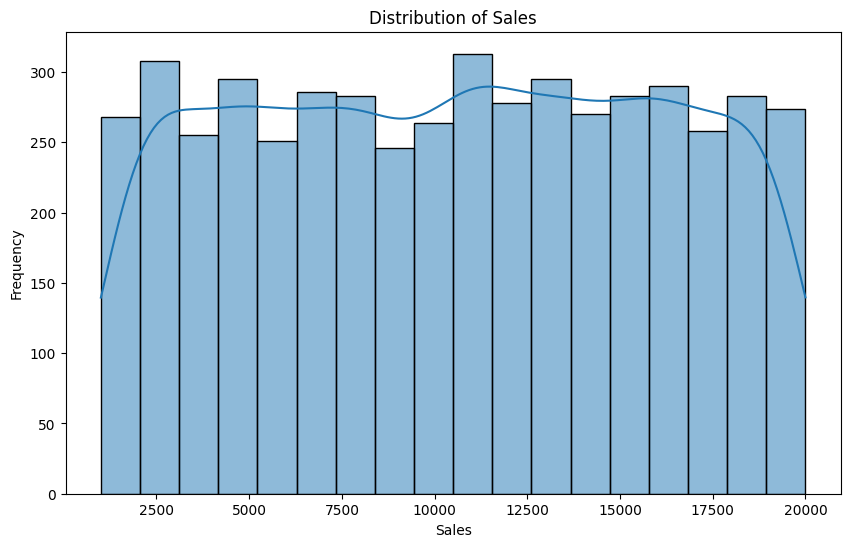

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_class = df.drop(['Sales', 'Sales_Category'], axis=1)
y_class = df['Sales_Category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Scale the classification features *after* the train-test split to prevent data leakage
scaler_class = StandardScaler()
X_train_c = scaler_class.fit_transform(X_train_c)
X_test_c = scaler_class.transform(X_test_c)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

y_pred_log = log_model.predict(X_test_c)

print("Logistic Regression Accuracy:", accuracy_score(y_test_c, y_pred_log))
print(classification_report(y_test_c, y_pred_log))

Logistic Regression Accuracy: 0.391
              precision    recall  f1-score   support

           0       0.37      0.61      0.46       357
           1       0.42      0.46      0.44       379
           2       0.00      0.00      0.00       264

    accuracy                           0.39      1000
   macro avg       0.26      0.36      0.30      1000
weighted avg       0.29      0.39      0.33      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
